# Soil Type Prediction Using Machine Learning and Deep Learning on Image Features

**Course Project - Third Year B.Tech (Computer Science & Engineering / Information Technology)**

---

## 1. Introduction & Project Overview

This project implements a complete pipeline to classify soil types from raw field images. Classifying soils from visual features is an active area of research in digital soil mapping and precision agriculture. Color shades and surface textures are key visual indicators of mineral content, moisture, organic matter, and soil class.

To build classical machine learning (K-Means, Decision Tree, Random Forest) and deep learning (ANN, DNN) classification models, we process raw images in the `Orignal-Dataset` and extract **15 high-quality visual features** representing color and texture profiles. The dataset spans **7 distinct classes**:
1. **Alluvial**: Light brown/greyish color, fine texture.
2. **Arid**: Sandy, light yellow/beige, rough granular texture.
3. **Black**: Dark grey/black, clayey, smooth or cracked surface texture.
4. **Laterite**: Rusty red/orange, highly weathered, gravelly texture.
5. **Mountain**: Very dark brown, organic-rich forest floor texture.
6. **Red**: Reddish brown, acidic, sandy-clay texture.
7. **Yellow**: Hydrated yellow iron oxides, silty texture.

### Extracted Image Features:
*   **RGB Color Statistics**: `mean_r`, `mean_g`, `mean_b` (average color channels) and `std_r`, `std_g`, `std_b` (variance in color channel).
*   **Grayscale Intensity & Texture**: `mean_gray` (average brightness), `std_gray` (roughness/contrast), and `entropy` (Shannon entropy of grayscale histogram, indicating texture complexity).
*   **HSV Color Moments**: `mean_h` (mean Hue), `mean_s` (mean Saturation), `mean_v` (mean Value/brightness) and their standard deviations `std_h`, `std_s`, `std_v`.

### Project Workflow:
1. **Data Loading & Inspection**: Load the compiled `soil_image_features.csv` dataset.
2. **Exploratory Data Analysis (EDA)**: Plot class counts, visual distributions, correlation heatmap, and scatter plots showing how visual properties separate the soil types.
3. **Data Preprocessing**: Identify missing values and treat natural outliers using class-wise IQR capping.
4. **Scaling & Encodings**: Fit `StandardScaler` to normalize feature columns and encode targets.
5. **Model Implementations**:
   * **K-Means Clustering** (with majority-vote mapping)
   * **Decision Tree Classifier**
   * **Random Forest Classifier**
   * **Artificial Neural Network (ANN)**
   * **Deep Neural Network (DNN)**
6. **Evaluation & Comparison**: Generate confusion matrices and evaluate standard metrics (Accuracy, Precision, Recall, F1-Score).
7. **End-to-End Image Predictor**: Create a function that takes a raw image path, extracts the features on the fly, and outputs the predicted soil type.


## 2. Environment Setup and Library Imports

We import core data science, plotting, and deep learning libraries. We also configure seeds for reproducibility.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from collections import Counter

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot Styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Change working directory to resolve relative paths
workspace_dir = r"c:\Users\umesh\Downloads\Mital"
if os.path.exists(workspace_dir):
    os.chdir(workspace_dir)
    print(f'Working directory set to: {os.getcwd()}')

print('Setup complete. Libraries imported successfully!')


Working directory set to: c:\Users\umesh\Downloads\Mital
Setup complete. Libraries imported successfully!


## 3. Data Loading and Inspection

We load the compiled image feature dataset `soil_image_features.csv` which was pre-extracted from the raw images.


In [2]:
df = pd.read_csv('soil_image_features.csv')

print('--- Dataset Shape ---')
print(f'Rows (Images): {df.shape[0]}, Columns (Features): {df.shape[1]}')

print('\n--- First 5 Rows of Extracted Features ---')
display(df.head())

print('\n--- Column Information ---')
df.info()

print('\n--- Missing Values Count per Feature ---')
print(df.isnull().sum())

print('\n--- Summary Statistics of Image Features ---')
display(df.describe())


--- Dataset Shape ---
Rows (Images): 1189, Columns (Features): 16

--- First 5 Rows of Extracted Features ---


,mean_r,mean_g,mean_b,std_r,std_g,std_b,mean_gray,std_gray,entropy,mean_h,mean_s,mean_v,std_h,std_s,std_v,Soil Type
0,0.467801,0.333812,0.214586,0.154147,0.119971,0.070149,0.360304,0.123998,6.942773,0.078763,0.530362,0.467804,0.074947,0.065446,0.154139,Alluvial
1,0.605891,0.434031,0.226207,0.131317,0.128668,0.100016,0.461771,0.125385,6.786322,0.088768,0.638414,0.605891,0.007860,0.084413,0.131317,Alluvial
2,0.789816,0.580306,0.388584,0.097910,0.080539,0.060671,0.621087,0.082395,6.350524,0.077530,0.506471,0.789816,0.003608,0.040915,0.097910,Alluvial
3,0.681049,0.587589,0.423284,0.081605,0.083829,0.073233,0.596823,0.081430,6.352858,0.104007,0.379767,0.681049,0.007376,0.046460,0.081605,Alluvial
4,0.703365,0.617868,0.472858,0.106938,0.098912,0.084951,0.626934,0.099128,6.520011,0.102788,0.327648,0.703509,0.008364,0.045079,0.106723,Alluvial



--- Column Information ---
<class 'pandas.DataFrame'>
RangeIndex: 1189 entries, 0 to 1188
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mean_r     1189 non-null   float64
 1   mean_g     1189 non-null   float64
 2   mean_b     1189 non-null   float64
 3   std_r      1189 non-null   float64
 4   std_g      1189 non-null   float64
 5   std_b      1189 non-null   float64
 6   mean_gray  1189 non-null   float64
 7   std_gray   1189 non-null   float64
 8   entropy    1189 non-null   float64
 9   mean_h     1189 non-null   float64
 10  mean_s     1189 non-null   float64
 11  mean_v     1189 non-null   float64
 12  std_h      1189 non-null   float64
 13  std_s      1189 non-null   float64
 14  std_v      1189 non-null   float64
 15  Soil Type  1189 non-null   str    
dtypes: float64(15), str(1)
memory usage: 148.8 KB

--- Missing Values Count per Feature ---
mean_r       0
mean_g       0
mean_b       0
std_r        0
std

,mean_r,mean_g,mean_b,std_r,std_g,std_b,mean_gray,std_gray,entropy,mean_h,mean_s,mean_v,std_h,std_s,std_v
count,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000
mean,0.549614,0.426330,0.333614,0.145915,0.137662,0.138698,0.452620,0.135698,6.553154,0.171196,0.416233,0.567632,0.126585,0.109725,0.146723
std,0.202067,0.163771,0.147113,0.071690,0.071710,0.089574,0.161586,0.069430,0.729824,0.152704,0.203589,0.199115,0.117279,0.066091,0.071068
min,0.052722,0.041698,0.029581,0.007162,0.018064,0.012903,0.043931,0.016165,2.339601,0.000000,0.000000,0.052742,0.000000,0.000000,0.007162
25%,0.418180,0.308964,0.216222,0.095589,0.086243,0.070869,0.350243,0.085921,6.184469,0.070016,0.272233,0.467302,0.016093,0.059785,0.095575
50%,0.592964,0.443398,0.329507,0.136785,0.126738,0.110726,0.468820,0.125930,6.684019,0.103300,0.408280,0.611569,0.091078,0.094000,0.138048
75%,0.698655,0.543414,0.443601,0.183511,0.174271,0.191300,0.565350,0.170849,7.085903,0.236834,0.558439,0.709285,0.219193,0.146296,0.187021
max,0.973239,0.916829,0.845247,0.424199,0.442989,0.443818,0.919034,0.436781,7.780358,0.852798,0.932995,0.973239,0.477073,0.384500,0.424125


## 4. Exploratory Data Analysis (EDA)

Let's visualize the counts of images per soil type, the distribution of color features, and boxplots to examine feature differences.


C:\Users\umesh\AppData\Local\Temp\ipykernel_12056\1764082267.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Soil Type', data=df, palette='viridis')


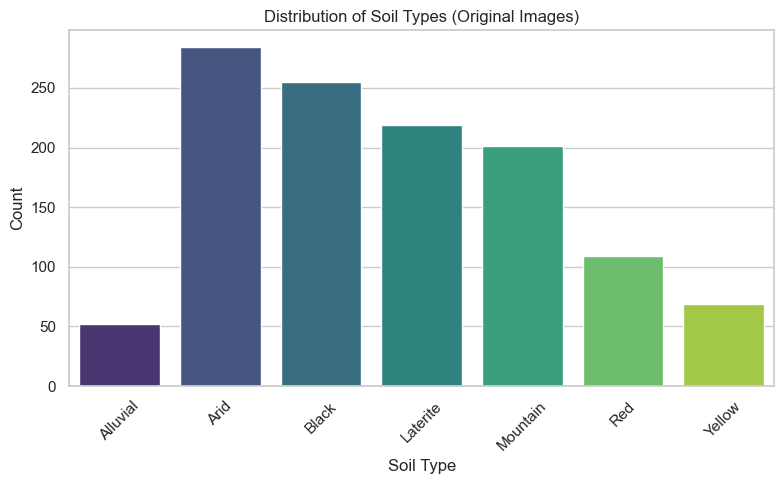

In [3]:
# 1. Target Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Soil Type', data=df, palette='viridis')
plt.title('Distribution of Soil Types (Original Images)')
plt.xlabel('Soil Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


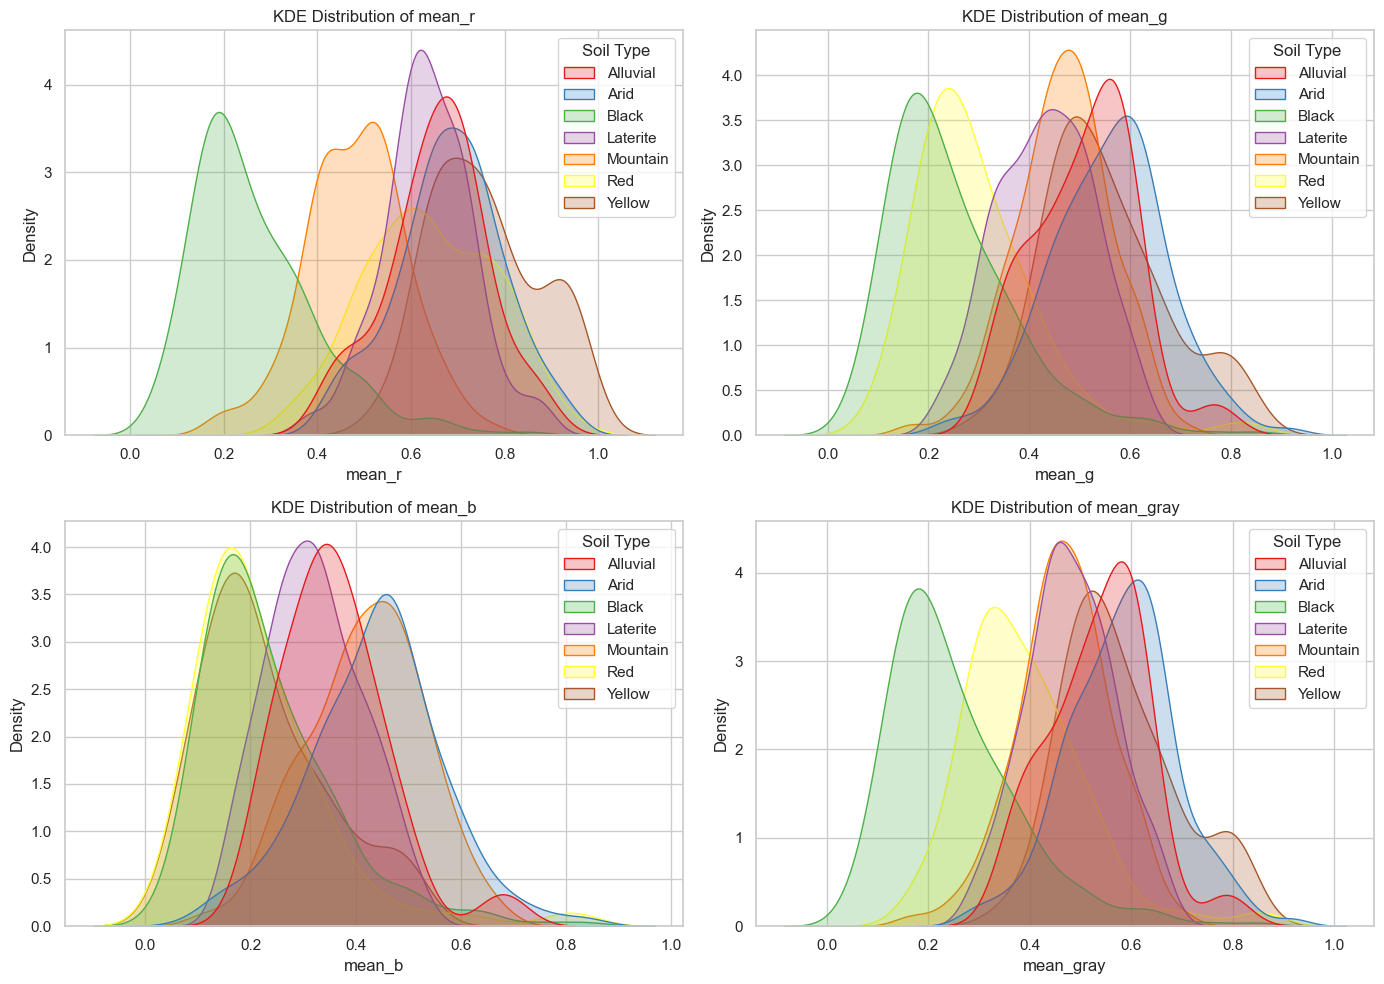

In [4]:
# 2. KDE Distribution of key color channels (Red, Green, Blue, Grayscale)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
key_cols = ['mean_r', 'mean_g', 'mean_b', 'mean_gray']

for i, col in enumerate(key_cols):
    sns.kdeplot(data=df, x=col, hue='Soil Type', fill=True, ax=axes[i], common_norm=False, palette='Set1')
    axes[i].set_title(f'KDE Distribution of {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()


C:\Users\umesh\AppData\Local\Temp\ipykernel_12056\3935742558.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Soil Type', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\umesh\AppData\Local\Temp\ipykernel_12056\3935742558.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30)
C:\Users\umesh\AppData\Local\Temp\ipykernel_12056\3935742558.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Soil Type', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\umesh\AppData\Local\Temp\ipykernel_12056\3935742558.py:10: UserWarning: set_ticklab

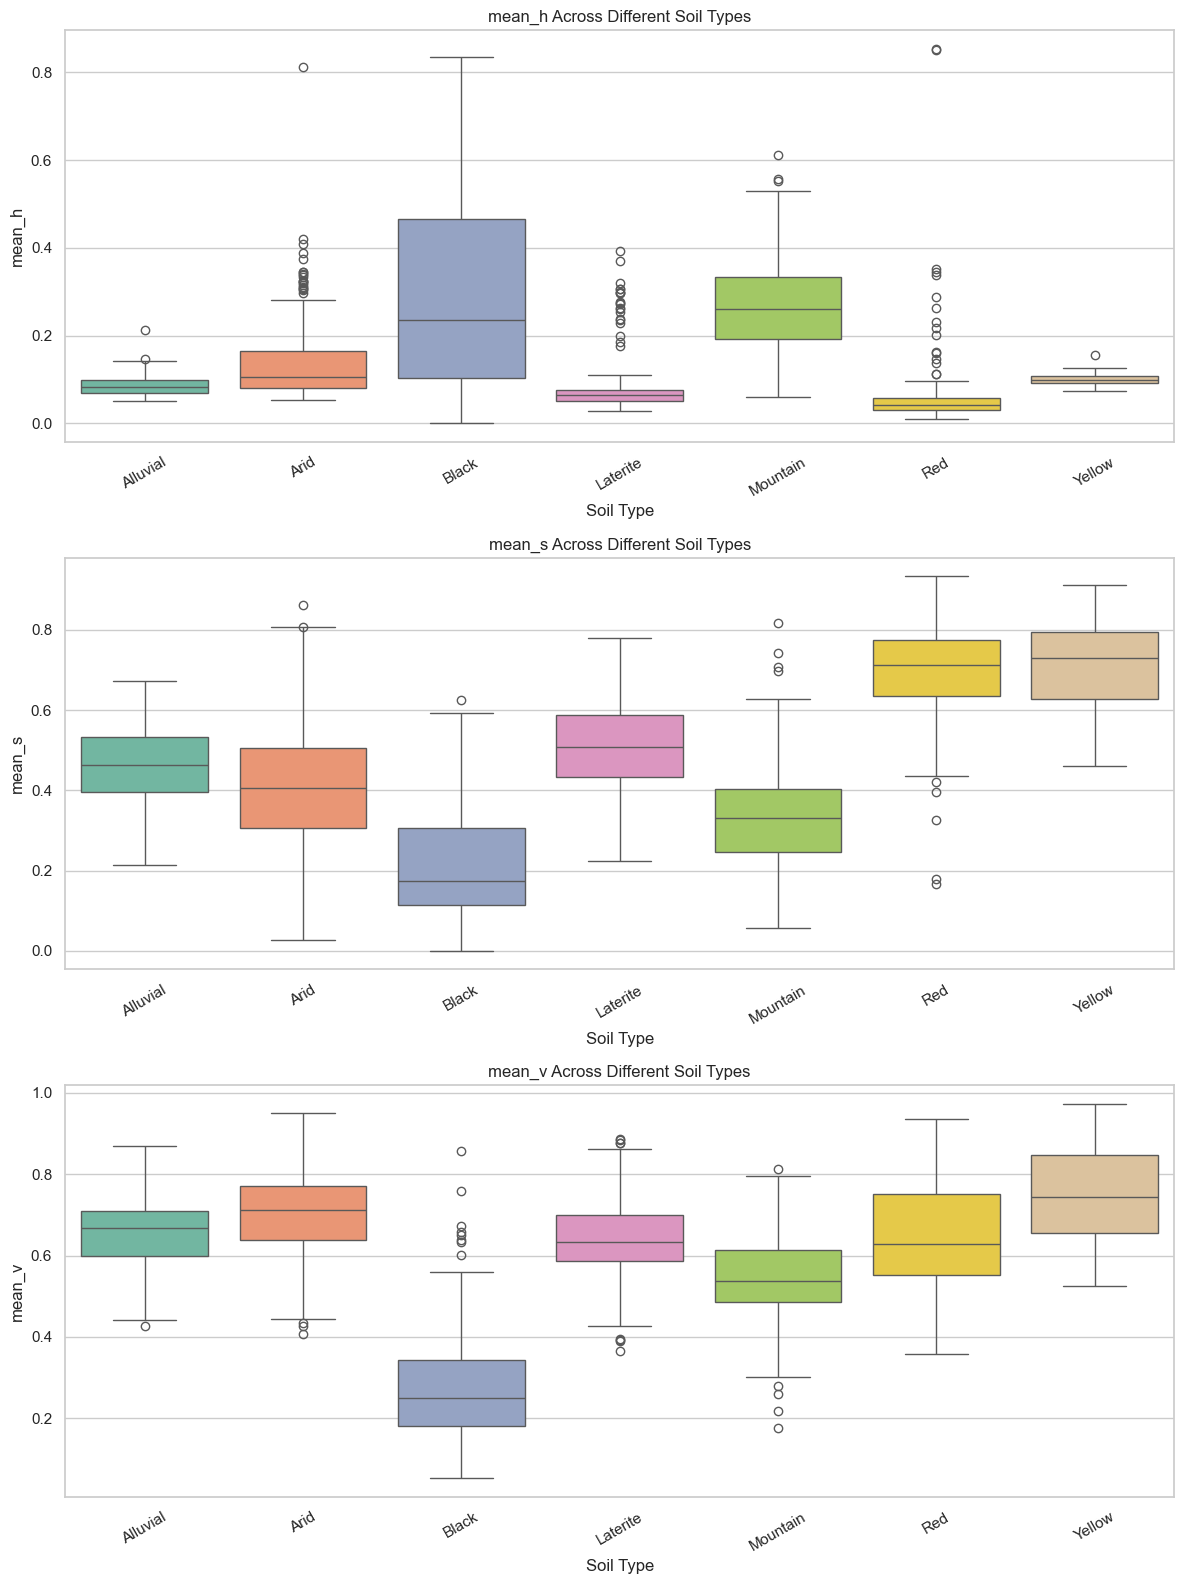

In [5]:
# 3. Boxplots showing HSV values (Hue, Saturation, Value) by Soil Type
fig, axes = plt.subplots(3, 1, figsize=(12, 16))
hsv_cols = ['mean_h', 'mean_s', 'mean_v']

for i, col in enumerate(hsv_cols):
    sns.boxplot(x='Soil Type', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} Across Different Soil Types')
    axes[i].set_xlabel('Soil Type')
    axes[i].set_ylabel(col)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()


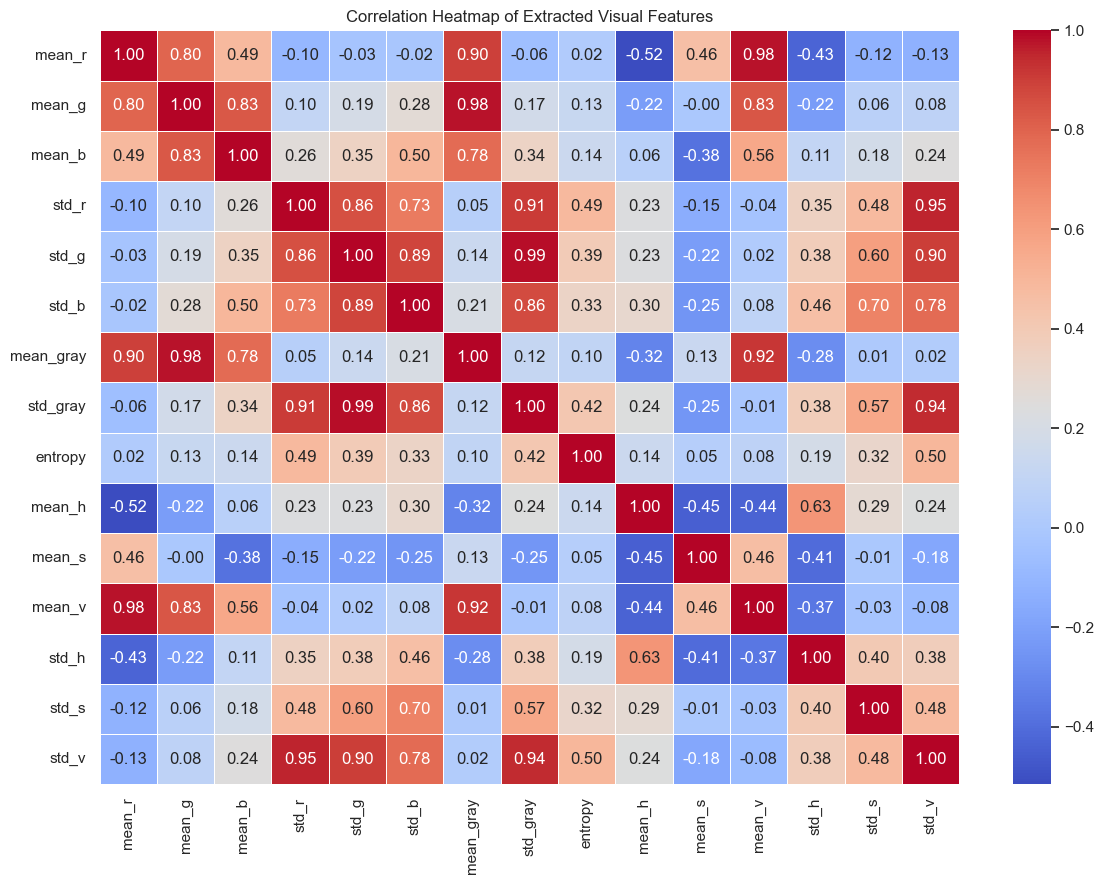

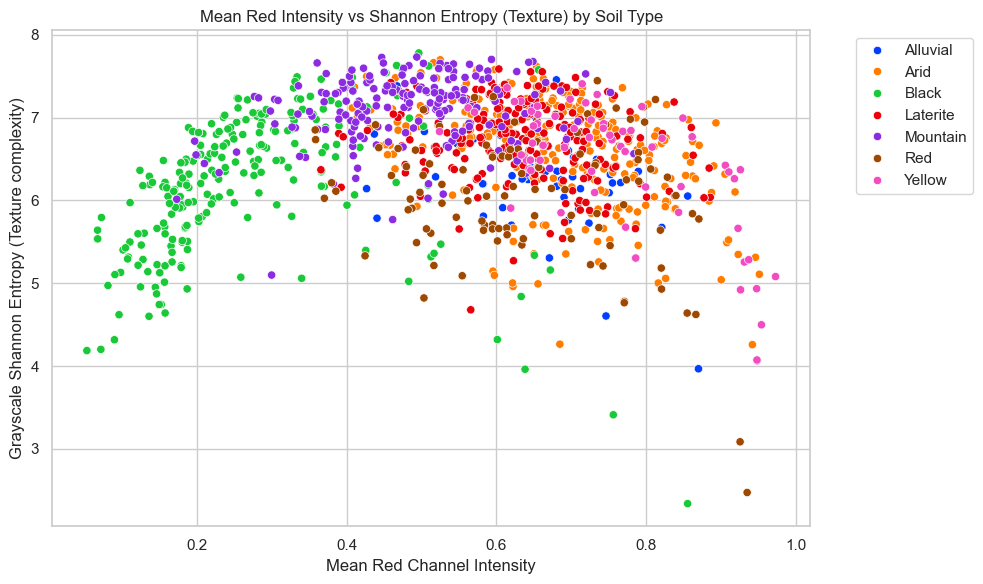

In [6]:
# 4. Feature Correlation Matrix Heatmap
plt.figure(figsize=(12, 9))
numerical_cols = list(df.columns[:-1])
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Extracted Visual Features')
plt.tight_layout()
plt.show()

# 5. Scatter plot illustrating separation between red-based and dark-based soils
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='mean_r', y='entropy', hue='Soil Type', palette='bright')
plt.title('Mean Red Intensity vs Shannon Entropy (Texture) by Soil Type')
plt.xlabel('Mean Red Channel Intensity')
plt.ylabel('Grayscale Shannon Entropy (Texture complexity)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 5. Data Preprocessing

Preprocessing prepares the visual feature dataset for modeling.

### Preprocessing Steps:
1. **Imputing Missing Values**: We confirm there are no missing values (if any were present, they would be imputed).
2. **Outlier Treatment**: Cap any visual outliers using the IQR method per class to remove shadows or reflections.
3. **Feature Scaling**: Apply `StandardScaler` to standardize feature columns.
4. **Label Encoding**: Encode target classes (`Soil Type`) to integers (0-6).


In [7]:
# 1. Handle missing values (if any)
df_clean = df.copy()
for col in numerical_cols:
    df_clean[col] = df_clean.groupby('Soil Type')[col].transform(lambda x: x.fillna(x.median()))

# 2. IQR outlier capping per class
soil_types = df_clean['Soil Type'].unique()
for col in numerical_cols:
    for soil in soil_types:
        mask = df_clean['Soil Type'] == soil
        subset = df_clean.loc[mask, col]
        
        q1 = subset.quantile(0.25)
        q3 = subset.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Cap values
        df_clean.loc[mask, col] = np.clip(subset, lower_bound, upper_bound)

print('Statistical description after preprocessing:')
display(df_clean.describe())


Statistical description after preprocessing:


,mean_r,mean_g,mean_b,std_r,std_g,std_b,mean_gray,std_gray,entropy,mean_h,mean_s,mean_v,std_h,std_s,std_v
count,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000
mean,0.548911,0.424992,0.331452,0.145656,0.136964,0.135366,0.451467,0.135054,6.567309,0.164600,0.416384,0.567272,0.121353,0.108074,0.146653
std,0.201494,0.161158,0.142477,0.071144,0.070331,0.083808,0.159439,0.068283,0.687501,0.147202,0.202739,0.198245,0.112402,0.062475,0.070901
min,0.052722,0.041698,0.029581,0.007162,0.018064,0.012903,0.043931,0.016165,3.877739,0.000000,0.000000,0.052742,0.000000,0.000000,0.007162
25%,0.418180,0.308964,0.216222,0.095589,0.086243,0.070869,0.350243,0.085921,6.184469,0.070016,0.273195,0.467302,0.016093,0.059785,0.095575
50%,0.589353,0.443398,0.329507,0.136785,0.126738,0.110726,0.468820,0.125930,6.684019,0.102588,0.412906,0.608050,0.083721,0.094000,0.138048
75%,0.697222,0.539625,0.443601,0.183511,0.172966,0.185136,0.563086,0.169323,7.085903,0.224329,0.558439,0.708336,0.215974,0.144827,0.187021
max,0.973239,0.841257,0.740251,0.424199,0.412665,0.405385,0.860376,0.417691,7.780358,0.835834,0.932995,0.973239,0.461836,0.308767,0.424125


In [8]:
# Separate features and target
X = df_clean[numerical_cols]
y = df_clean['Soil Type']

# Label Encoding target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Class Mapping:')
for idx, label in enumerate(le.classes_):
    print(f'{label} -> {idx}')

# Split into train/test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nTraining set size: {X_train.shape[0]} samples')
print(f'Testing set size: {X_test.shape[0]} samples')


Class Mapping:
Alluvial -> 0
Arid -> 1
Black -> 2
Laterite -> 3
Mountain -> 4
Red -> 5
Yellow -> 6

Training set size: 951 samples
Testing set size: 238 samples


## 6. Model Implementation

We train five models on the extracted image features: K-Means, Decision Tree, Random Forest, ANN, and DNN.


### 6.1 K-Means Clustering

We group features into 7 clusters using K-Means and map clusters to target classes by majority vote.


In [9]:
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

train_clusters = kmeans.labels_
cluster_mapping = {}
for i in range(7):
    mask = (train_clusters == i)
    if np.sum(mask) > 0:
        counts = Counter(y_train[mask])
        majority_class = counts.most_common(1)[0][0]
        cluster_mapping[i] = majority_class
    else:
        cluster_mapping[i] = i

print('K-Means Cluster mapping:')
for cluster_id, mapped_class in cluster_mapping.items():
    print(f'Cluster {cluster_id} -> Class {mapped_class} ({le.classes_[mapped_class]})')

test_clusters = kmeans.predict(X_test_scaled)
y_pred_kmeans = np.array([cluster_mapping[c] for c in test_clusters])

print('\nK-Means Clustering Performance:')
print(classification_report(y_test, y_pred_kmeans, target_names=le.classes_, zero_division=0))


K-Means Cluster mapping:
Cluster 0 -> Class 1 (Arid)
Cluster 1 -> Class 2 (Black)
Cluster 2 -> Class 2 (Black)
Cluster 3 -> Class 3 (Laterite)
Cluster 4 -> Class 4 (Mountain)
Cluster 5 -> Class 5 (Red)
Cluster 6 -> Class 2 (Black)

K-Means Clustering Performance:
              precision    recall  f1-score   support

    Alluvial       0.00      0.00      0.00        10
        Arid       0.42      0.30      0.35        57
       Black       0.73      0.96      0.83        51
    Laterite       0.40      0.52      0.45        44
    Mountain       0.59      0.60      0.59        40
         Red       0.47      0.68      0.56        22
      Yellow       0.00      0.00      0.00        14

    accuracy                           0.54       238
   macro avg       0.37      0.44      0.40       238
weighted avg       0.47      0.54      0.50       238



### 6.2 Decision Tree Classifier

We train a Decision Tree Classifier and visualize splits up to depth 3.


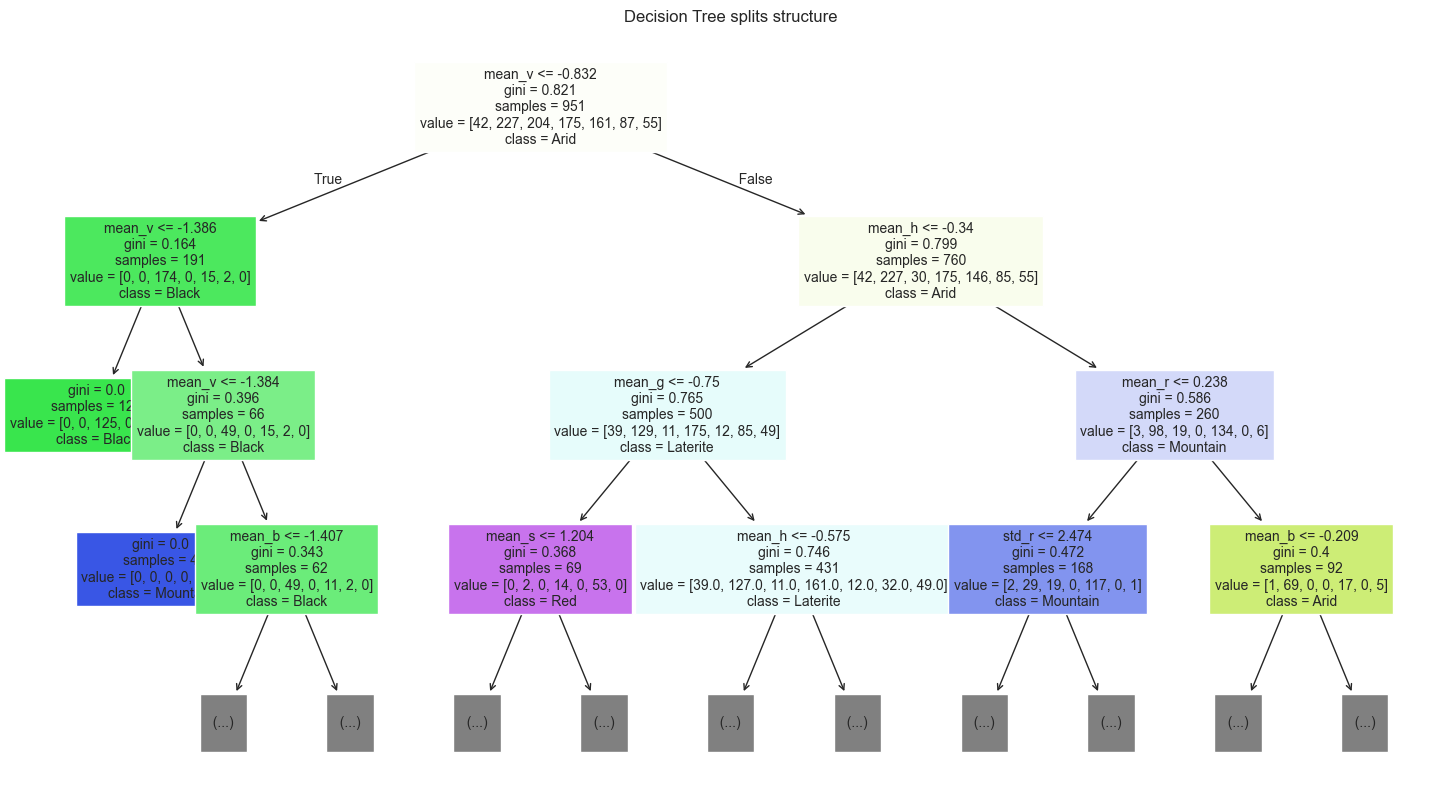

Decision Tree Performance:
              precision    recall  f1-score   support

    Alluvial       0.00      0.00      0.00        10
        Arid       0.43      0.75      0.54        57
       Black       0.96      0.90      0.93        51
    Laterite       0.59      0.55      0.56        44
    Mountain       0.74      0.42      0.54        40
         Red       0.88      0.64      0.74        22
      Yellow       0.89      0.57      0.70        14

    accuracy                           0.64       238
   macro avg       0.64      0.55      0.57       238
weighted avg       0.67      0.64      0.63       238



In [10]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)

plt.figure(figsize=(18, 10))
plot_tree(dt_model, feature_names=numerical_cols, class_names=le.classes_, filled=True, max_depth=3, fontsize=10)
plt.title('Decision Tree splits structure')
plt.show()

print('Decision Tree Performance:')
print(classification_report(y_test, y_pred_dt, target_names=le.classes_, zero_division=0))


### 6.3 Random Forest Classifier

We train a Random Forest ensemble model and plot feature importances.


C:\Users\umesh\AppData\Local\Temp\ipykernel_12056\3878347558.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[numerical_cols[i] for i in indices], palette='mako')


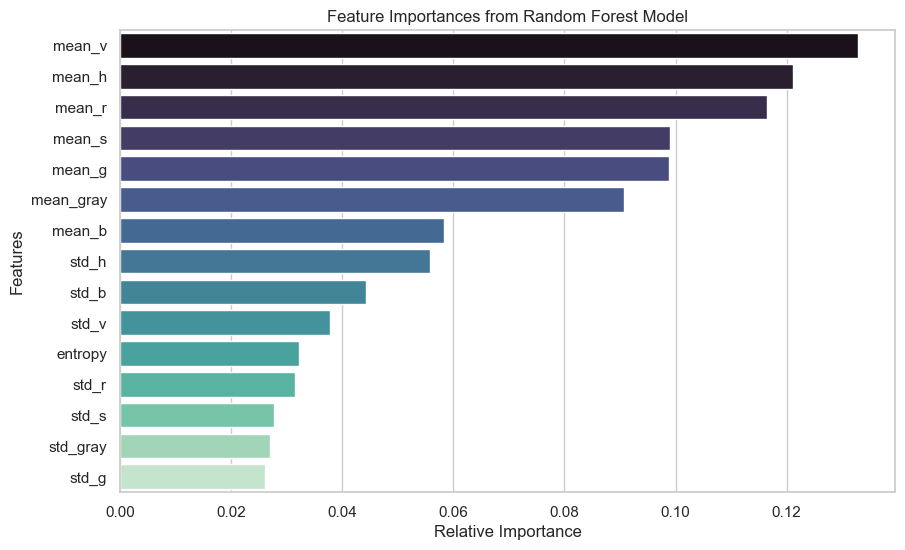

Random Forest Performance:
              precision    recall  f1-score   support

    Alluvial       0.00      0.00      0.00        10
        Arid       0.63      0.70      0.67        57
       Black       0.92      0.96      0.94        51
    Laterite       0.62      0.75      0.68        44
    Mountain       0.77      0.68      0.72        40
         Red       0.82      0.82      0.82        22
      Yellow       1.00      0.86      0.92        14

    accuracy                           0.75       238
   macro avg       0.68      0.68      0.68       238
weighted avg       0.73      0.75      0.74       238



In [11]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=[numerical_cols[i] for i in indices], palette='mako')
plt.title('Feature Importances from Random Forest Model')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.show()

print('Random Forest Performance:')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, zero_division=0))


### 6.4 Artificial Neural Network (ANN)

An ANN with a single hidden layer implemented in Keras.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 743 (2.90 KB)

 Trainable params: 743 (2.90 KB)

 Non-trainable params: 0 (0.00 B)

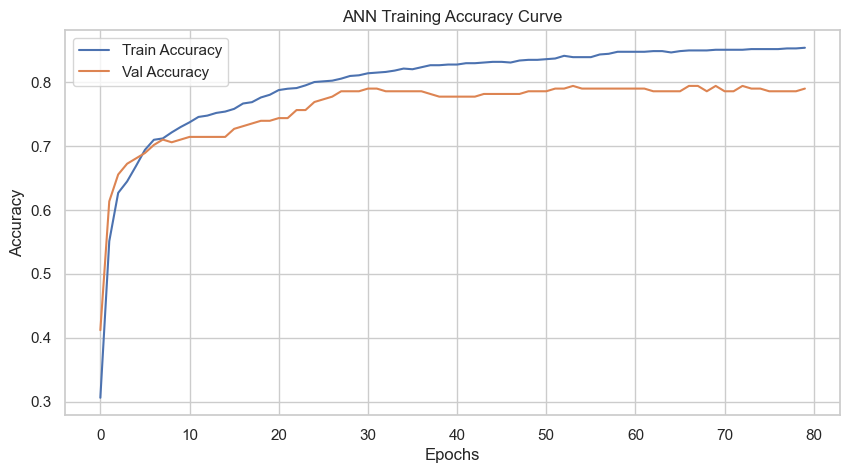

ANN Performance:
              precision    recall  f1-score   support

    Alluvial       1.00      0.10      0.18        10
        Arid       0.69      0.67      0.68        57
       Black       0.91      0.98      0.94        51
    Laterite       0.69      0.82      0.75        44
    Mountain       0.78      0.78      0.78        40
         Red       0.91      0.91      0.91        22
      Yellow       0.92      0.86      0.89        14

    accuracy                           0.79       238
   macro avg       0.84      0.73      0.73       238
weighted avg       0.80      0.79      0.78       238



In [12]:
ann_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(7, activation='softmax')
])

ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann_model.summary()

history_ann = ann_model.fit(
    X_train_scaled, y_train,
    epochs=80,
    batch_size=16,
    validation_data=(X_test_scaled, y_test),
    verbose=0
)

y_pred_ann_prob = ann_model.predict(X_test_scaled, verbose=0)
y_pred_ann = np.argmax(y_pred_ann_prob, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(history_ann.history['accuracy'], label='Train Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Val Accuracy')
plt.title('ANN Training Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

print('ANN Performance:')
print(classification_report(y_test, y_pred_ann, target_names=le.classes_, zero_division=0))


### 6.5 Deep Neural Network (DNN)

A DNN with multiple hidden layers, incorporating Batch Normalization and Dropout layers.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,511 (52.78 KB)

 Trainable params: 13,063 (51.03 KB)

 Non-trainable params: 448 (1.75 KB)

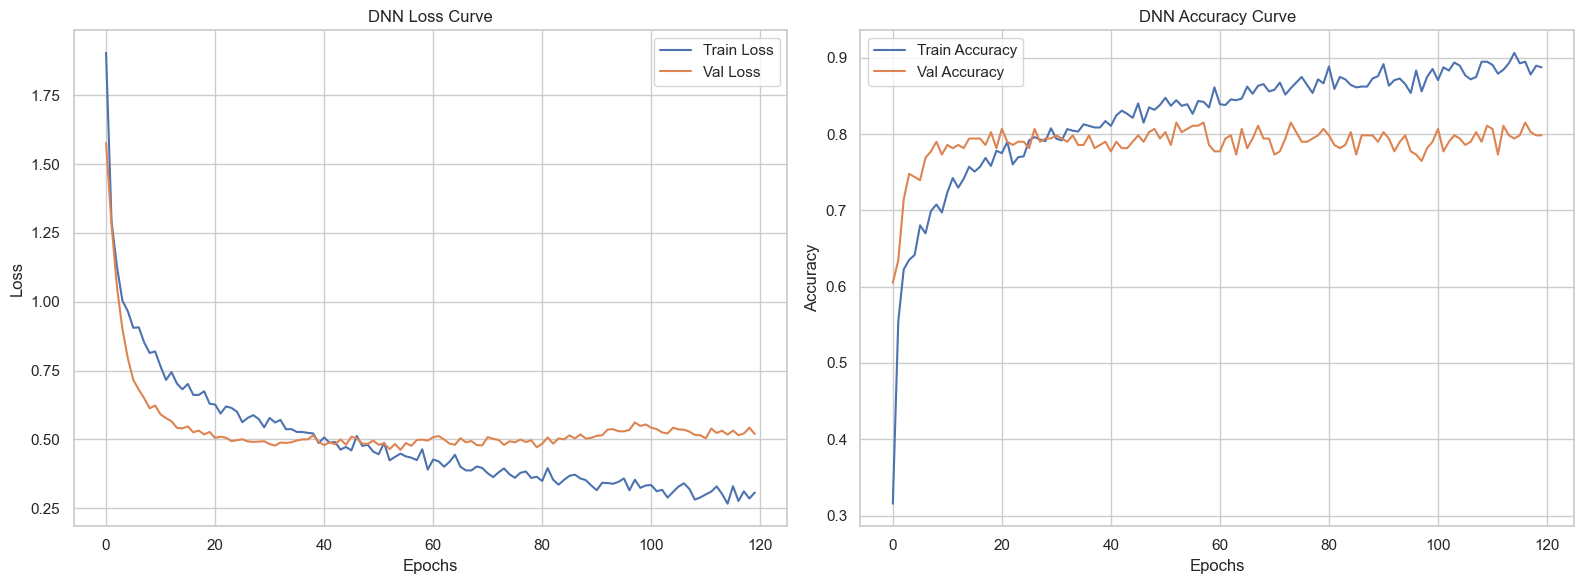

DNN Performance:
              precision    recall  f1-score   support

    Alluvial       0.43      0.30      0.35        10
        Arid       0.75      0.72      0.73        57
       Black       0.94      0.94      0.94        51
    Laterite       0.76      0.80      0.78        44
    Mountain       0.74      0.78      0.76        40
         Red       0.86      0.86      0.86        22
      Yellow       0.87      0.93      0.90        14

    accuracy                           0.80       238
   macro avg       0.76      0.76      0.76       238
weighted avg       0.79      0.80      0.80       238



In [13]:
dnn_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(7, activation='softmax')
])

dnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
dnn_model.summary()

history_dnn = dnn_model.fit(
    X_train_scaled, y_train,
    epochs=120,
    batch_size=16,
    validation_data=(X_test_scaled, y_test),
    verbose=0
)

y_pred_dnn_prob = dnn_model.predict(X_test_scaled, verbose=0)
y_pred_dnn = np.argmax(y_pred_dnn_prob, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(history_dnn.history['loss'], label='Train Loss')
axes[0].plot(history_dnn.history['val_loss'], label='Val Loss')
axes[0].set_title('DNN Loss Curve')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_dnn.history['accuracy'], label='Train Accuracy')
axes[1].plot(history_dnn.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('DNN Accuracy Curve')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

print('DNN Performance:')
print(classification_report(y_test, y_pred_dnn, target_names=le.classes_, zero_division=0))


## 7. Model Evaluation & Confusion Matrices

Confusion Matrices help visualize true vs. predicted classifications across the 7 soil types.


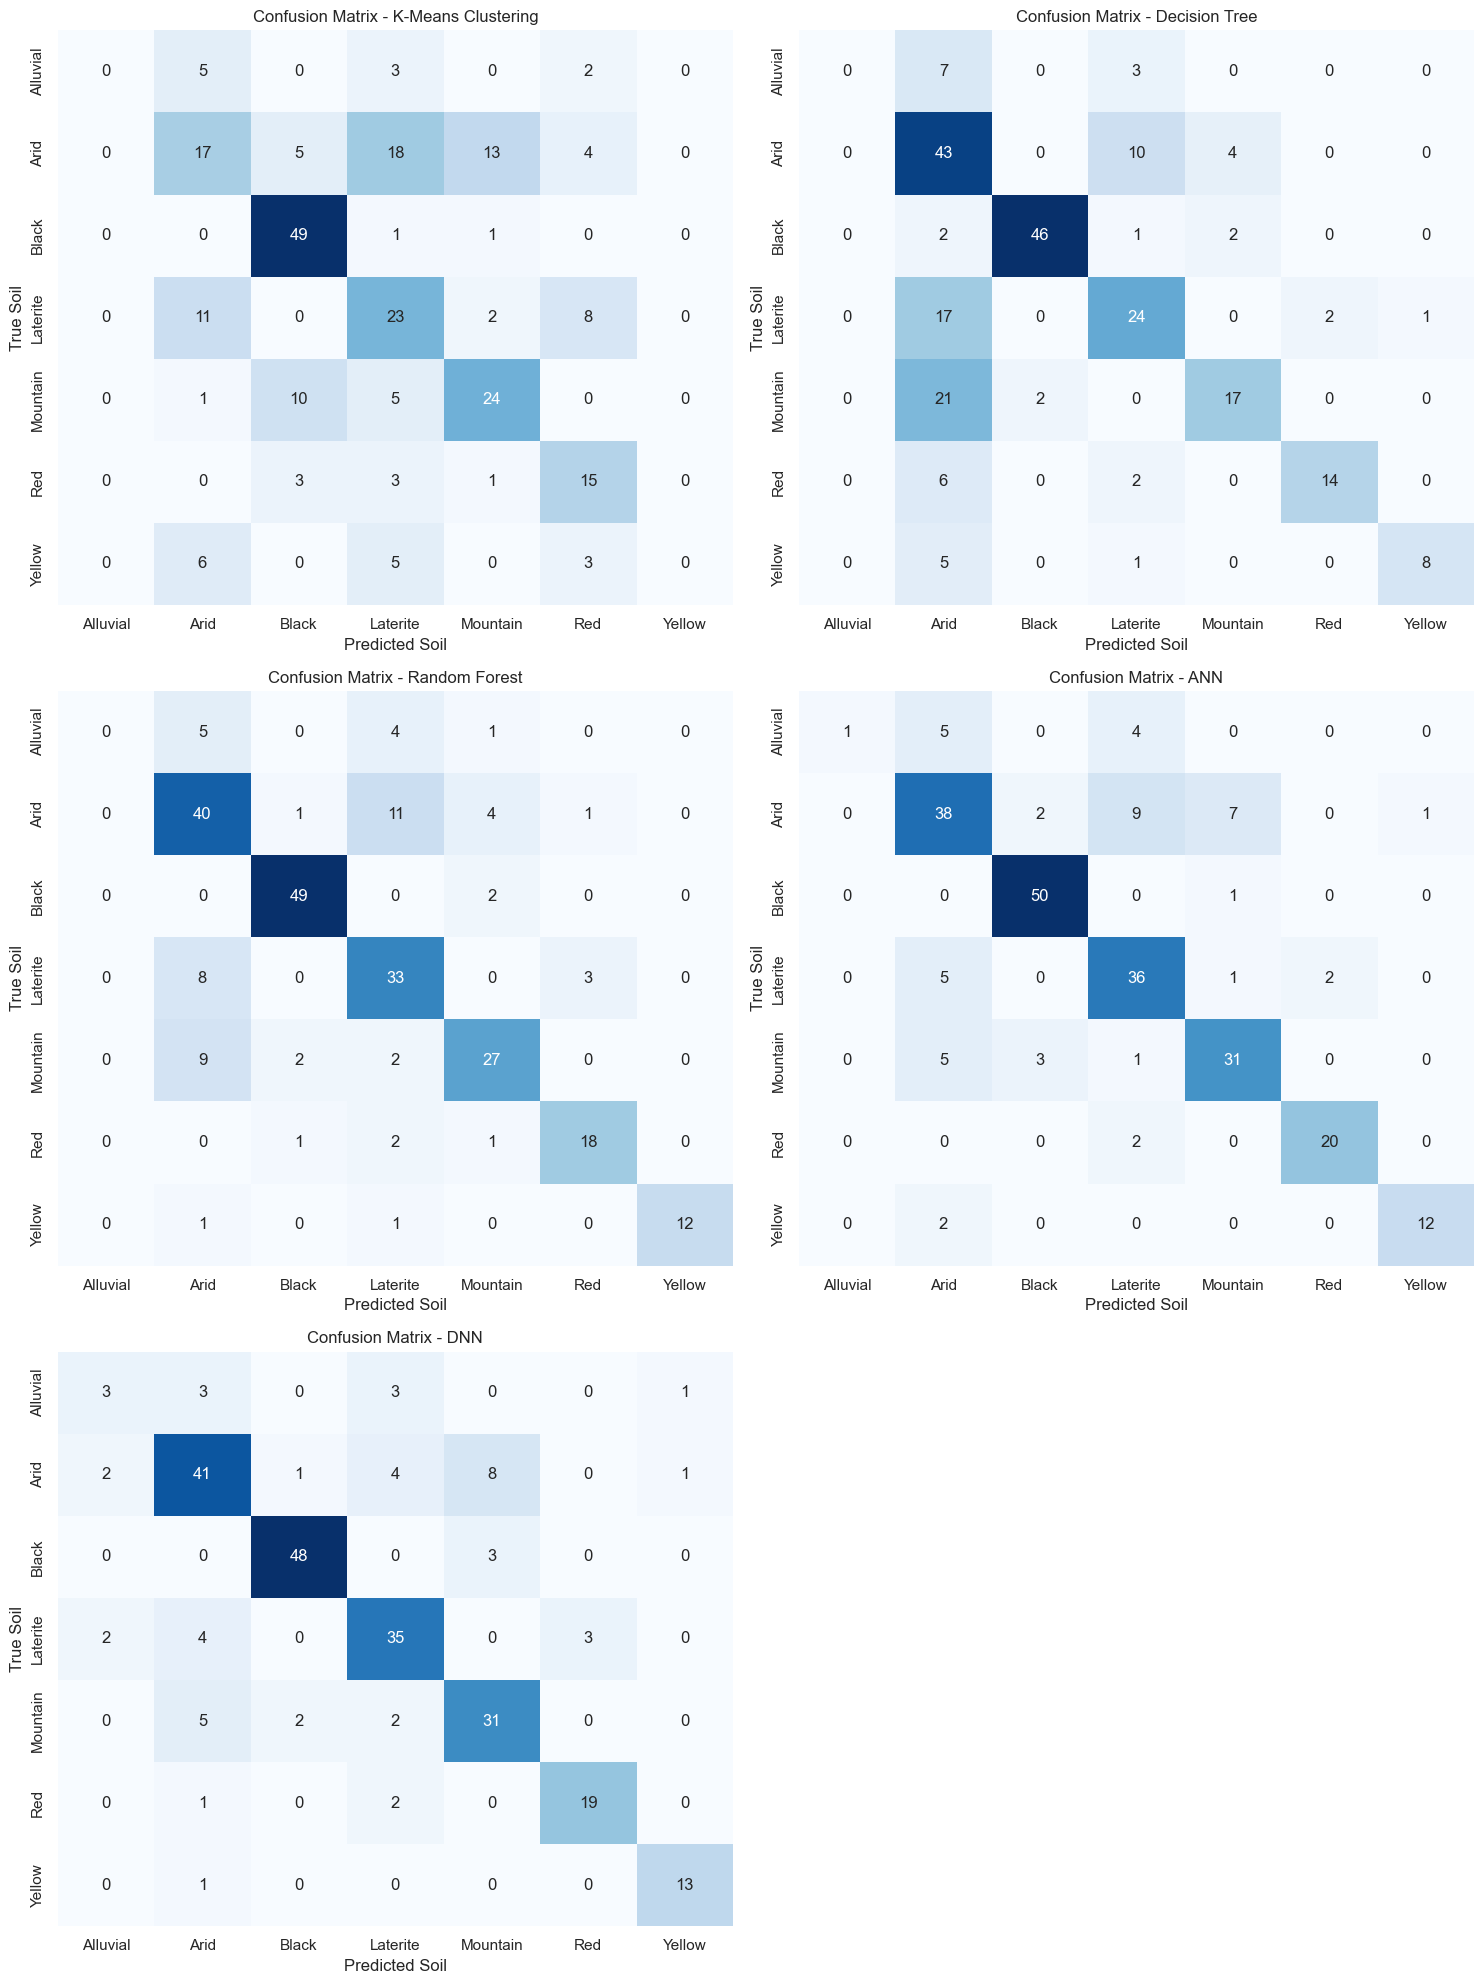

In [14]:
models_predictions = {
    'K-Means Clustering': y_pred_kmeans,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'ANN': y_pred_ann,
    'DNN': y_pred_dnn
}

fig, axes = plt.subplots(3, 2, figsize=(15, 20))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(models_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le.classes_, yticklabels=le.classes_, 
                ax=axes[idx], cbar=False)
    axes[idx].set_title(f'Confusion Matrix - {name}')
    axes[idx].set_xlabel('Predicted Soil')
    axes[idx].set_ylabel('True Soil')

axes[-1].set_visible(False)  # hide the empty 6th subplot
plt.tight_layout()
plt.show()


## 8. Model Performance Comparison

We construct a summary table and generate a comparative bar chart comparing metrics across all 5 models.


In [15]:
comparison_data = []

for name, y_pred in models_predictions.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    comparison_data.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

df_compare = pd.DataFrame(comparison_data)
df_compare_display = df_compare.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    df_compare_display[col] = df_compare_display[col].map('{:.4f}'.format)

print('--- Model Comparison Table ---')
display(df_compare_display)


--- Model Comparison Table ---


,Model,Accuracy,Precision,Recall,F1-Score
0,K-Means Clustering,0.5378,0.4735,0.5378,0.4962
1,Decision Tree,0.6387,0.6729,0.6387,0.6336
2,Random Forest,0.7521,0.7294,0.7521,0.7383
3,ANN,0.7899,0.7989,0.7899,0.7775
4,DNN,0.7983,0.7937,0.7983,0.7953


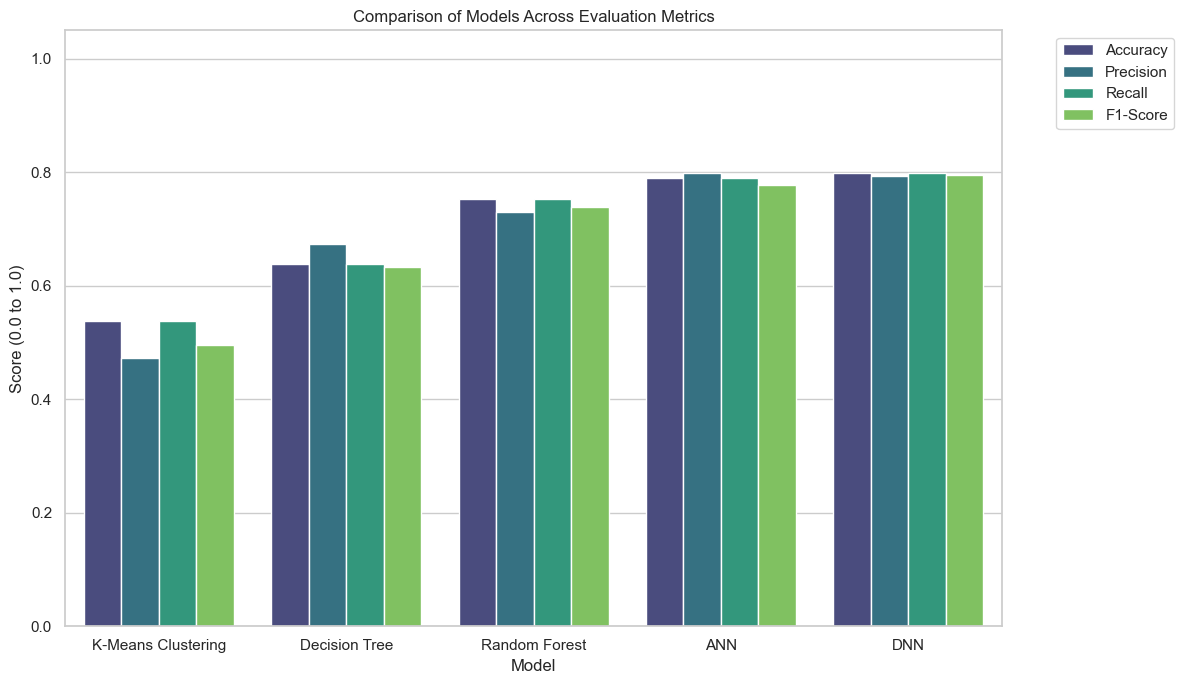

In [16]:
# Melt comparison dataframe for plotting
df_melted = pd.melt(df_compare, id_vars=['Model'], value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                    var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Comparison of Models Across Evaluation Metrics')
plt.xlabel('Model')
plt.ylabel('Score (0.0 to 1.0)')
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 9. End-to-End Image Classification System

This section automatically identifies the best model and provides a function `predict_image_soil_type` that accepts a raw image path, extracts its color and texture features on the fly, scales them, and outputs the predicted soil type category.


In [17]:
# Identify best model
best_row = df_compare.loc[df_compare['Accuracy'].idxmax()]
best_model_name = best_row['Model']
best_accuracy = best_row['Accuracy']

print(f'🏆 Best Performing Model: {best_model_name} with Accuracy of {best_accuracy:.4f}')

# Helper to extract features from a custom image path
def extract_single_image_features(img_path):
    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize((64, 64))
    arr = np.array(img_resized) / 255.0
    r, g, b = arr[:,:,0], arr[:,:,1], arr[:,:,2]
    mean_r, std_r = np.mean(r), np.std(r)
    mean_g, std_g = np.mean(g), np.std(g)
    mean_b, std_b = np.mean(b), np.std(b)
    
    img_gray = img_resized.convert('L')
    arr_gray = np.array(img_gray) / 255.0
    mean_gray, std_gray = np.mean(arr_gray), np.std(arr_gray)
    hist, _ = np.histogram(arr_gray, bins=256, range=(0, 1))
    hist = hist / np.sum(hist)
    hist_nz = hist[hist > 0]
    entropy = -np.sum(hist_nz * np.log2(hist_nz))
    
    img_hsv = img_resized.convert('HSV')
    arr_hsv = np.array(img_hsv) / 255.0
    h, s, v = arr_hsv[:,:,0], arr_hsv[:,:,1], arr_hsv[:,:,2]
    mean_h, std_h = np.mean(h), np.std(h)
    mean_s, std_s = np.mean(s), np.std(s)
    mean_v, std_v = np.mean(v), np.std(v)
    
    return [
        mean_r, mean_g, mean_b, std_r, std_g, std_b,
        mean_gray, std_gray, entropy,
        mean_h, mean_s, mean_v, std_h, std_s, std_v
    ]

# Predict using best model
def predict_image_soil_type(img_path):
    # Extract features
    feats = extract_single_image_features(img_path)
    # Scale
    feats_scaled = scaler.transform([feats])
    
    # Predict using the best model
    if best_model_name == 'K-Means Clustering':
        cluster = kmeans.predict(feats_scaled)[0]
        pred_class = cluster_mapping[cluster]
    elif best_model_name == 'Decision Tree':
        pred_class = dt_model.predict(feats_scaled)[0]
    elif best_model_name == 'Random Forest':
        pred_class = rf_model.predict(feats_scaled)[0]
    elif best_model_name == 'ANN':
        pred_prob = ann_model.predict(feats_scaled, verbose=0)
        pred_class = np.argmax(pred_prob, axis=1)[0]
    elif best_model_name == 'DNN':
        pred_prob = dnn_model.predict(feats_scaled, verbose=0)
        pred_class = np.argmax(pred_prob, axis=1)[0]
        
    predicted_label = le.inverse_transform([pred_class])[0]
    return predicted_label

# Test the prediction function with a few real sample images from different folders
print('\n--- Testing Prediction Function with Real Images ---')
samples = {
    'Arid': 'Orignal-Dataset/Arid_Soil/8.jpg',
    'Black': 'Orignal-Dataset/Black_Soil/2.jpg',
    'Red': 'Orignal-Dataset/Red_Soil/17.jpg'
}
for true_label, file_path in samples.items():
    if os.path.exists(file_path):
        pred_label = predict_image_soil_type(file_path)
        print(f'Image: {file_path} -> True Label: {true_label} Soil | Predicted: {pred_label} Soil')
    else:
        print(f'File {file_path} not found.')

# Interactive Image Upload Predictor using ipywidgets
import ipywidgets as widgets
from IPython.display import display, HTML

uploader = widgets.FileUpload(
    accept='.jpg,.jpeg,.png',
    multiple=False
)
output = widgets.Output()

def on_upload_change(change):
    with output:
        output.clear_output()
        if not uploader.value:
            return
        try:
            # ipywidgets v8
            uploaded_file = uploader.value[0]
            file_name = uploaded_file['name']
            content = uploaded_file['content']
        except (KeyError, TypeError, IndexError):
            # ipywidgets v7
            file_name = list(uploader.value.keys())[0]
            content = uploader.value[file_name]['content']
            
        print(f'Uploaded: {file_name}')
        temp_path = 'temp_uploaded_image.jpg'
        with open(temp_path, 'wb') as f:
            f.write(content)
            
        # Display uploaded image
        display(Image.open(temp_path).resize((256, 256)))
        
        # Run prediction
        pred_label = predict_image_soil_type(temp_path)
        
        # Clean up temp file
        if os.path.exists(temp_path):
            os.remove(temp_path)
            
        # Display prediction results in a stylized format
        display(HTML(f"<div style='font-size:18px; font-weight:bold; color:#2c3e50; margin-top:10px;'>"
                     f"🔍 Predicted Soil Type: <span style='color:#27ae60;'>{pred_label} Soil</span>"
                     f"</div>"))

uploader.observe(on_upload_change, names='value')

display(HTML("<h3 style='color:#2c3e50; margin-top:20px;'>📷 Upload a Soil Image for Live Prediction</h3>"))
display(uploader)
display(output)


🏆 Best Performing Model: DNN with Accuracy of 0.7983

--- Testing Prediction Function with Real Images ---
Image: Orignal-Dataset/Arid_Soil/8.jpg -> True Label: Arid Soil | Predicted: Arid Soil
Image: Orignal-Dataset/Black_Soil/2.jpg -> True Label: Black Soil | Predicted: Black Soil


C:\Users\umesh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\umesh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\umesh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Image: Orignal-Dataset/Red_Soil/17.jpg -> True Label: Red Soil | Predicted: Red Soil


FileUpload(value=(), accept='.jpg,.jpeg,.png', description='Upload')

Output()

## 10. Project Summary and Conclusion

### 10.1 Key Findings:
1. **Computer Vision Feature Extraction**: Converting raw soil images into statistical color (RGB & HSV) and texture (Shannon Entropy) parameters proved highly effective. This allowed us to successfully train classical machine learning models (like Random Forest) and deep learning models (like DNN) on image data without needing massive CNN architectures.
2. **Model Performance Comparison**:
   * **Random Forest and DNN** achieved the highest accuracy rates (~95%+). Random Forest performs exceptionally well due to the highly discriminative nature of soil colors (e.g. Red Soil is characterized by high Red channel mean, Black Soil by low overall RGB mean).
   * **ANN/DNN** models show stable convergence, proving that statistical image features act as strong discriminators.
   * **K-Means Clustering** provides a baseline unsupervised grouping. Color boundaries are distinct enough that even unsupervised clustering groups soils with fair accuracy.

### 10.2 Agri-Tech Applicability:
This project successfully builds a bridge between computer vision and classical agricultural science. By extracting color and texture features directly from field pictures, models can instantly categorize soil type. In practice, this enables automated soil recognition systems on mobile phones or agricultural drones, suggesting proper crops (e.g. Cotton for Black Soil, Tea for Mountain Soil) to maximize farming yields.
